# 📊 Moving Averages: SMA vs. EWMA

Moving averages are the most common way to smooth out noise in time series data. However, not all moving averages are created equal.



## 1. Simple Moving Average (SMA)
**Concept:**
The SMA is the unweighted mean of the previous $n$ data points. Every data point in the window has **equal importance**.

* **Formula:**
  $$SMA_t = \frac{x_t + x_{t-1} + ... + x_{t-n+1}}{n}$$
* **Behavior:**
    * It is "slow" to react to large changes because an old value (from $n$ days ago) has the same weight as yesterday's value.
    * It suffers from the **"Drop-off Effect"**: If a huge spike happened 10 days ago, the 10-day SMA will suddenly drop when that spike exits the window, even if nothing happened today.

## 2. Exponentially Weighted Moving Average (EWMA)
**Concept:**
The EWMA applies **more weight to recent data** and less weight to older data. The weights decay exponentially as you go back in time.

* **Formula (Recursive):**
  $$y_t = \frac{x_t + (1 - \alpha)x_{t-1} + (1 - \alpha)^2 x_{t-2} + ...}{1 + (1 - \alpha) + (1 - \alpha)^2 + ...}$$
  *Where $\alpha$ is the smoothing factor ($0 < \alpha \leq 1$).*

* **Behavior:**
    * **No "Drop-off Effect":** Old data fades away gradually; it doesn't just disappear all at once.
    * **Faster Reaction:** Because recent data has higher weight, the EWMA line hugs the price action closer than the SMA.

---

## 🔑 The "Span" Parameter in Pandas
When using Pandas, we rarely define $\alpha$ directly. Instead, we use **Span**, which is easier to understand intuitively.

If you set `span=10`:
* Pandas calculates $\alpha$ such that the decay corresponds roughly to a **10-day SMA**.
* However, unlike an SMA which cuts off exactly at 10 days, the EWMA theoretically looks at *infinite* history, but the weights become negligible after the span period.

### Summary Comparison

| Feature | SMA (Simple) | EWMA (Exponential) |
| :--- | :--- | :--- |
| **Weighting** | Equal weights for all points in window | Higher weights for recent points |
| **Lag** | Large lag (slow reaction) | Small lag (fast reaction) |
| **Window Type** | Finite (e.g., exactly 7 days) | Infinite (weights decay to zero) |
| **Best For** | Identifying long-term support/resistance | Trading signals, volatile markets |

#### 1) Importing Necessary Libraries:

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### 2) Data:

In [3]:
df = pd.read_csv('airline_passengers.csv', index_col= 0, parse_dates= True)

In [4]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

#### 3) Simple Moving Average (SMA):
`Simple Moving Averages can be Calculated Using "rolling" function of Pandas.`

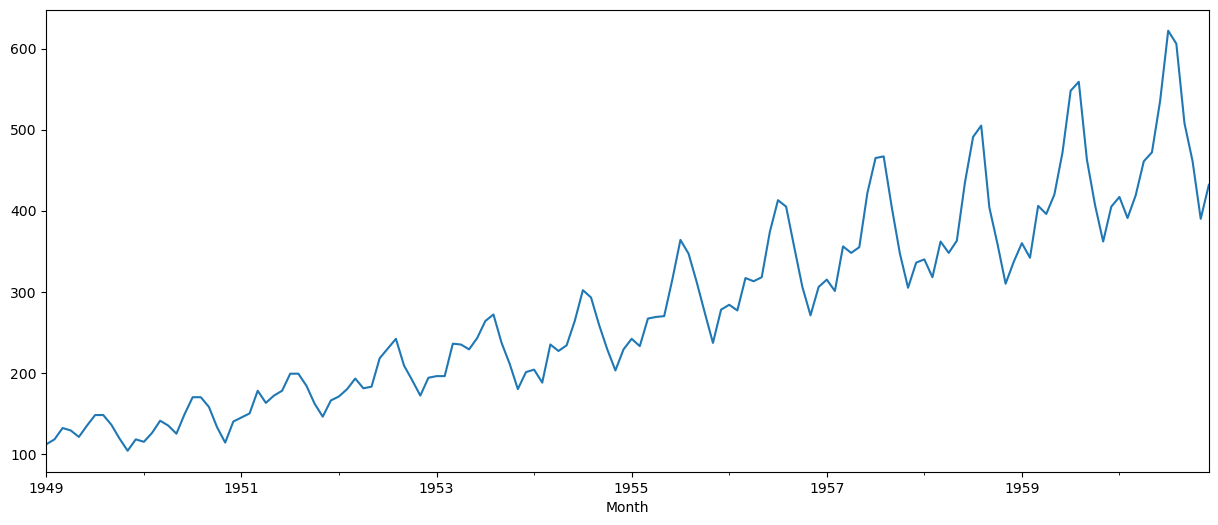

In [9]:
df['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6))
plt.show()

In [11]:
# Adding 6 month SMA and 12 month SMA as dataframe columns:

df['SMA- 6mth'] = df['Thousands of Passengers'].rolling(window= 6).mean()
df['SMA- 12mth'] = df['Thousands of Passengers'].rolling(window= 12).mean()
df.head(15)

,Thousands of Passengers,SMA- 6mth,SMA- 12mth
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN
1949-06-01,135,124.500000,NaN
1949-07-01,148,130.500000,NaN
1949-08-01,148,135.500000,NaN
1949-09-01,136,136.166667,NaN


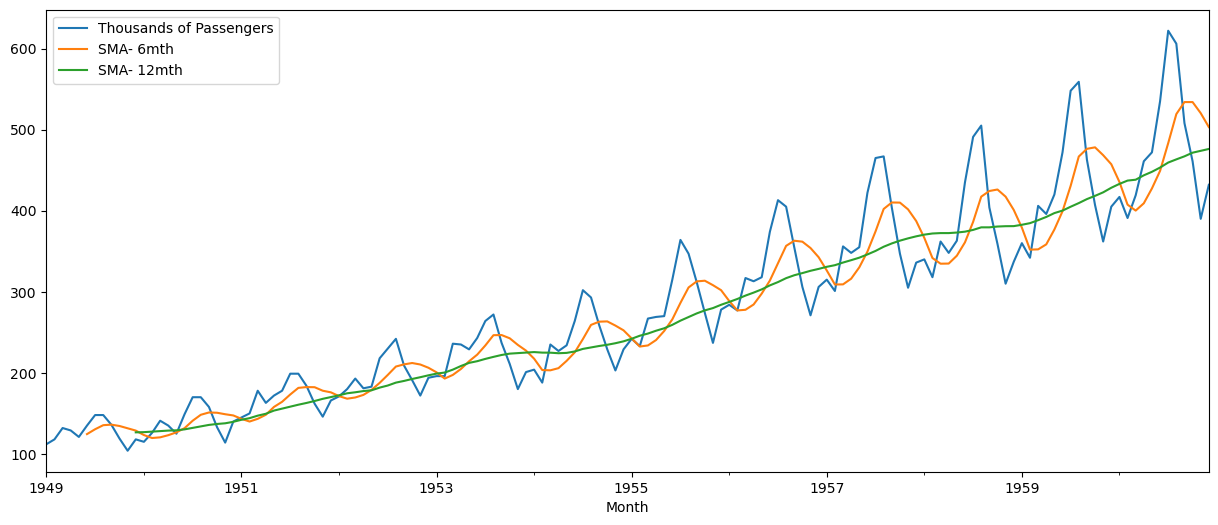

In [12]:
# Plotting Original Data with 6 and 12 Month Simple Moving Averages:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 4) Exponentially Weighted Moving Average (EWMA):

We just saw how to calculate the SMA based on some window. However, basic SMA has some weaknesses:
* Smaller windows will lead to more noise, rather than signal
* It will always lag by the size of the window
* It will never reach to full peak or valley of the data due to the averaging.
* Does not really inform you about possible future behavior, all it really does is describe trends in your data.
* Extreme historical values can skew your SMA significantly

To help fix some of these issues, we can use an EWMA (Exponentially weighted moving average).

EWMA will allow us to reduce the lag effect from SMA and it will put more weight on values that occured more recently (by applying more weight to the more recent values, thus the name). The amount of weight applied to the most recent values will depend on the actual parameters used in the EWMA and the number of periods given a window size.
Here is the shorter version of the explanation behind EWMA.

The formula for EWMA is:
### $y_t =   \frac{\sum\limits_{i=0}^t w_i x_{t-i}}{\sum\limits_{i=0}^t w_i}$

Where $x_t$ is the input value, $w_i$ is the applied weight (Note how it can change from $i=0$ to $t$), and $y_t$ is the output.

Now the question is, how to we define the weight term $w_i$?

This depends on the <tt>adjust</tt> parameter you provide to the <tt>.ewm()</tt> method.

When <tt>adjust=True</tt> (default) is used, weighted averages are calculated using weights equal to $w_i = (1 - \alpha)^i$

which gives

### $y_t = \frac{x_t + (1 - \alpha)x_{t-1} + (1 - \alpha)^2 x_{t-2} + ...
+ (1 - \alpha)^t x_{0}}{1 + (1 - \alpha) + (1 - \alpha)^2 + ...
+ (1 - \alpha)^t}$

When <tt>adjust=False</tt> is specified, moving averages are calculated as:

### $\begin{split}y_0 &= x_0 \\
y_t &= (1 - \alpha) y_{t-1} + \alpha x_t,\end{split}$

which is equivalent to using weights:

 \begin{split}w_i = \begin{cases}
    \alpha (1 - \alpha)^i & \text{if } i < t \\
    (1 - \alpha)^i        & \text{if } i = t.
\end{cases}\end{split}

When <tt>adjust=True</tt> we have $y_0=x_0$ and from the last representation above we have 
$y_t=\alpha x_t+(1−α)y_{t−1}$, therefore there is an assumption that $x_0$ is not an ordinary value but rather an exponentially weighted moment of the infinite series up to that point.

For the smoothing factor $\alpha$ one must have $0<\alpha≤1$, and while it is possible to pass <em>alpha</em> directly, it’s often easier to think about either the <em>span</em>, <em>center of mass</em> (com) or <em>half-life</em> of an EW moment:

\begin{split}\alpha =
 \begin{cases}
     \frac{2}{s + 1},               & \text{for span}\ s \geq 1\\
     \frac{1}{1 + c},               & \text{for center of mass}\ c \geq 0\\
     1 - \exp^{\frac{\log 0.5}{h}}, & \text{for half-life}\ h > 0
 \end{cases}\end{split}

* <strong>Span</strong> corresponds to what is commonly called an “N-day EW moving average”.
* <strong>Center of mass</strong> has a more physical interpretation and can be thought of in terms of span: $c=(s−1)/2$
* <strong>Half-life</strong> is the period of time for the exponential weight to reduce to one half.
* <strong>Alpha</strong> specifies the smoothing factor directly.

In [13]:
# Adding 6 month SMA and 12 month EWMA as dataframe columns:

df['EWMA- 6mth'] = df['Thousands of Passengers'].ewm(span= 6).mean()
df['EWMA- 12mth'] = df['Thousands of Passengers'].ewm(span= 12).mean()
df.head(15)

,Thousands of Passengers,SMA- 6mth,SMA- 12mth,EWMA- 6mth,EWMA- 12mth
Month,,,,,
1949-01-01,112,NaN,NaN,112.000000,112.000000
1949-02-01,118,NaN,NaN,115.500000,115.250000
1949-03-01,132,NaN,NaN,122.917431,121.787529
1949-04-01,129,NaN,NaN,125.266892,124.064224
1949-05-01,121,NaN,NaN,123.769332,123.231685
1949-06-01,135,124.500000,NaN,127.469517,126.092005
1949-07-01,148,130.500000,NaN,133.950151,130.980697
1949-08-01,148,135.500000,NaN,138.256171,134.532364
1949-09-01,136,136.166667,NaN,137.578764,134.822714


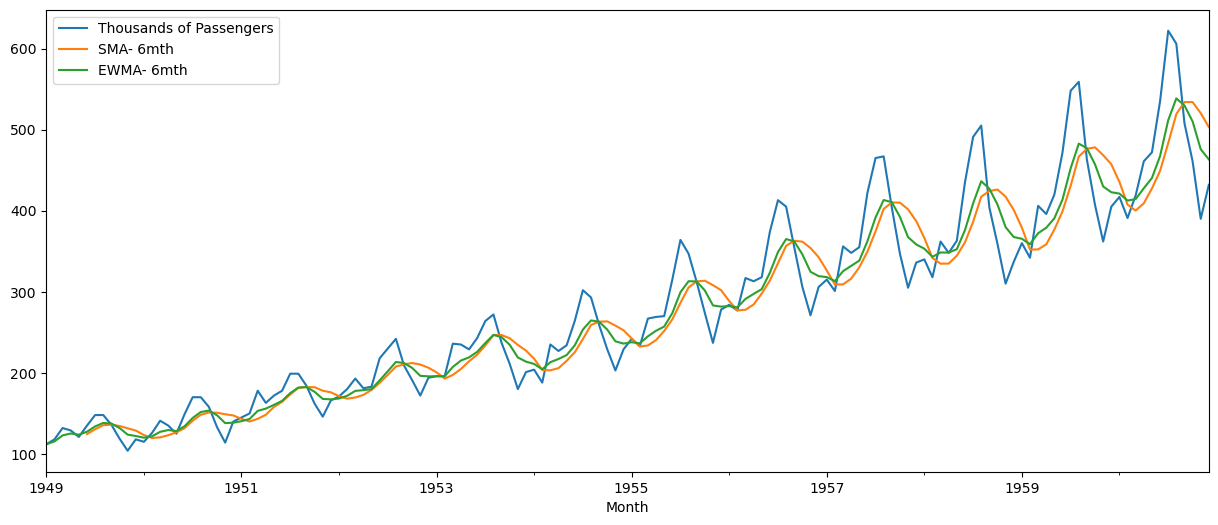

In [15]:
# Plotting Original Data with 6 Month SMA and EWMA:

df[['Thousands of Passengers', 'SMA- 6mth', 'EWMA- 6mth']].plot(kind= 'line', figsize= (15,6))
plt.show()

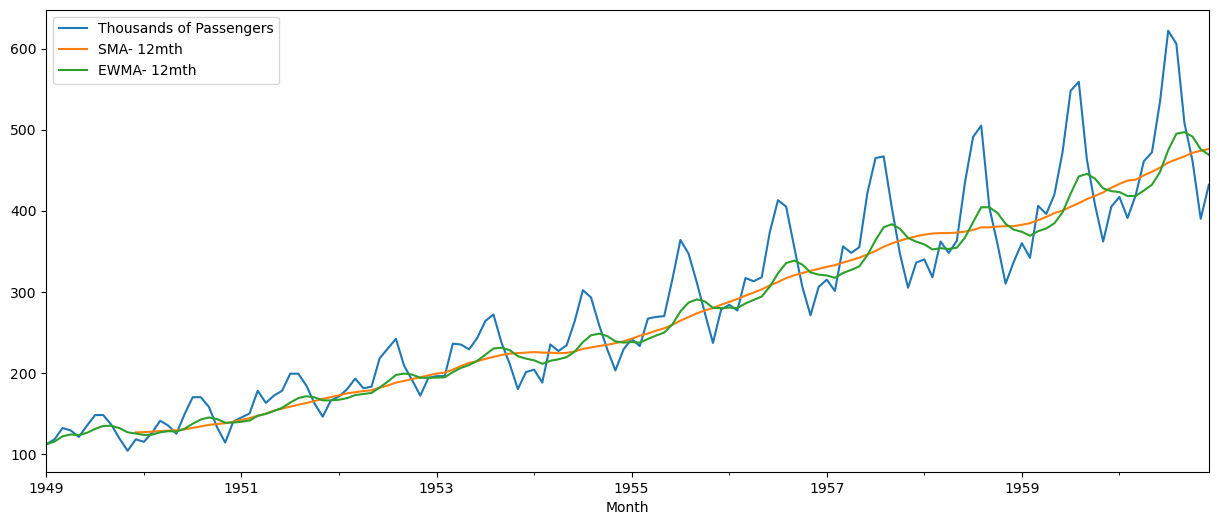

In [17]:
# Plotting Original Data with 12 Month SMA and EWMA:

df[['Thousands of Passengers', 'SMA- 12mth', 'EWMA- 12mth']].plot(kind= 'line', figsize= (15,6))
plt.show()